# MERFISH S2R3 to S2R2

This report reproduces the uncertainty analysis described for the
MERFISH mouse-brain benchmark in the paper. The query is Vizgen section **S2R3**
(85,958 cells) and the reference is section **S2R2** (84,172 cells).

Ten independent replicates retain 80% of the cells from each original section.
The complete cross-sample workflow was re-estimated for every replicate, so the
variation propagated through structure construction, pre-alignment,
rasterization, and S-LDDMM. The analysis measures the stability of those learned
transformations; it is not a calibrated probability or confidence interval.

Data source: [Vizgen Mouse Brain Receptor Map](https://info.vizgen.com/mouse-brain-map).

**Fixed-seed reproducibility.** This workflow uses seed `1000`. Keep the same input order and parameters, including `restore_best=False`, and set the seed before sampling. The fitted transformations were validated by two independent fixed-seed executions. This report reuses those transformations and summarizes their mean-distance metric.

## 1. Experimental design

For each replicate, cells were sampled independently without replacement using
fixed replicate- and sample-specific seeds. The upstream workflow comprised:

1. per-sample BANKSY representation learning;
2. PCA, Harmony integration, and SNN Leiden clustering at resolution 1.4;
3. boundary-aware spatial-structure refinement;
4. weighted shared-centroid Procrustes pre-alignment with scaling and no reflection;
5. multichannel structure-composition and density pseudo-images; and
6. S-LDDMM registration.

The prepared `.npz` files used below are the outputs of steps 1–5 for each
independent replicate. This report runs or loads step 6, applies all ten saved
transformations to a common evaluation support, and regenerates the pointwise
variability figures and tables.

### Adapting the subsampling design

The ten 80% replicates are an experimental design choice, not an S-LDDMM
default. For another dataset, retain enough observations to preserve important
structures and use enough independent repeats to stabilize the distribution
tail. Re-run clustering, pre-alignment, rasterization and S-LDDMM independently
for every replicate, then evaluate every learned transformation on one fixed
support. Report the retained fraction, replicate seeds, input ordering and full
alignment configuration.

## 2. Setup

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spAlignDE

WORKFLOW_SEED = 1000
seed_controls = spAlignDE.set_random_seed(
    WORKFLOW_SEED,
    deterministic_torch=True,
)

from spAlignDE import uncertainty as uq

PROJECT_ROOT = Path.cwd().resolve()
INPUT_DIR = Path(
    os.environ.get(
        "SPALIGNDE_UNCERTAINTY_INPUT_DIR",
        PROJECT_ROOT / "data" / "cross_sample" / "mouse_brain" / "uncertainty" / "lddmm_inputs",
    )
)
OUTPUT_DIR = Path(
    os.environ.get(
        "SPALIGNDE_UNCERTAINTY_OUTPUT_DIR",
        PROJECT_ROOT / "outputs" / "cross_sample_uncertainty",
    )
)
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

uq.set_plot_style()

if not INPUT_DIR.exists():
    raise FileNotFoundError(
        f"Prepared replicate inputs were not found at {INPUT_DIR}. "
        "Place lddmm_input_rep01.npz through lddmm_input_rep10.npz there, "
        "or set SPALIGNDE_UNCERTAINTY_INPUT_DIR."
    )

print("Input set: 10 prepared LDDMM replicates")
print("Output directory:", OUTPUT_DIR.name)

Input set: 10 prepared LDDMM replicates
Output directory: outputs


## 3. Validate the ten 80% replicates

The source count is 68,766 in every replicate (80% of 85,958, rounded down),
and the reference count is 67,337 (80% of 84,172, rounded down).

In [2]:
repeat_inputs = uq.discover_lddmm_inputs(INPUT_DIR)
assert [item["repeat"] for item in repeat_inputs] == list(range(1, 11))

replicate_rows = []
for item in repeat_inputs:
    dat = uq.load_repeat_input(item["path"])
    replicate_rows.append(
        {
            "replicate": item["repeat"],
            "query_cells": len(dat["x_src_prealign"]),
            "reference_cells": len(dat["x_tgt"]),
            "prealignment": str(np.asarray(dat.get("prealign_method", "unknown")).item()),
        }
    )

replicate_table = pd.DataFrame(replicate_rows)
assert len(replicate_table) == 10
assert set(replicate_table["query_cells"]) == {68_766}
assert set(replicate_table["reference_cells"]) == {67_337}
display(replicate_table)

,replicate,query_cells,reference_cells,prealignment
0,1,68766,67337,shared_cluster_weighted_procrustes
1,2,68766,67337,shared_cluster_weighted_procrustes
2,3,68766,67337,shared_cluster_weighted_procrustes
3,4,68766,67337,shared_cluster_weighted_procrustes
4,5,68766,67337,shared_cluster_weighted_procrustes
5,6,68766,67337,shared_cluster_weighted_procrustes
6,7,68766,67337,shared_cluster_weighted_procrustes
7,8,68766,67337,shared_cluster_weighted_procrustes
8,9,68766,67337,shared_cluster_weighted_procrustes
9,10,68766,67337,shared_cluster_weighted_procrustes


## 4. Run or load the replicate S-LDDMM transformations

`FORCE_RERUN=False` uses the transformations already generated with the paper's
parameters. Set it to `True` to re-estimate all ten transformations. The output
directory is controlled by ``SPALIGNDE_UNCERTAINTY_OUTPUT_DIR`` and defaults to
``outputs/cross_sample_uncertainty`` under the notebook working directory.

The reported workflow explicitly retains the final optimizer iterate
(`restore_best=False`). This setting is part of the reported analysis: changing
it returns different transformations even though the logged final energy
history is unchanged.

In [3]:
FORCE_RERUN = os.environ.get("SPALIGNDE_FORCE_UNCERTAINTY_RERUN", "0") == "1"

model_cfg = {
    "a": 300,
    "p": 2.0,
    "expand": 2.0,
    "nt": 3,
    "grid_step": 100,
}
optim_cfg = {
    "niter": 500,
    "diffeo_start": 0,
    "lrL": 2e-8,
    "lrT": 2e-1,
    "lrM": 2e3,
    "affine_slowdown": 10.0,
    "grad_clip_m0": None,
    "lrM_decay": 1.0,
    "lrM_min": 2e3,
    "restore_best": False,
}

aligned_by_repeat, run_summary = uq.run_or_load_alignments(
    repeat_inputs,
    output_dir=OUTPUT_DIR,
    model_cfg=model_cfg,
    optim_cfg=optim_cfg,
    force=FORCE_RERUN,
    save_transforms=True,
    require_transforms=True,
    verbose=False,
)
display(
    run_summary[
        ["repeat", "status", "n_source_points", "n_target_points", "prealign_method", "finalE", "elapsed_sec"]
    ]
)
print("Checkpoint policy: final optimizer iterate (restore_best=False)")

,repeat,status,n_source_points,n_target_points,prealign_method,finalE,elapsed_sec
0,1,cached,68766,67337,shared_cluster_weighted_procrustes,8576.507463,24.384582
1,2,cached,68766,67337,shared_cluster_weighted_procrustes,8147.642341,37.227651
2,3,cached,68766,67337,shared_cluster_weighted_procrustes,9315.090842,22.424113
3,4,cached,68766,67337,shared_cluster_weighted_procrustes,8190.309770,23.700048
4,5,cached,68766,67337,shared_cluster_weighted_procrustes,8412.782143,37.017846
5,6,cached,68766,67337,shared_cluster_weighted_procrustes,8477.063799,22.186356
6,7,cached,68766,67337,shared_cluster_weighted_procrustes,8424.620902,36.918995
7,8,cached,68766,67337,shared_cluster_weighted_procrustes,8592.896435,39.251236
8,9,cached,68766,67337,shared_cluster_weighted_procrustes,8424.799445,23.450687
9,10,cached,68766,67337,shared_cluster_weighted_procrustes,8555.501515,36.909800


Checkpoint policy: final optimizer iterate (restore_best=False)


## 5. Replicate-level alignment quality control

These panels overlay each independently subsampled query result on the
replicate-1 reference subset as a common visual background. Inspect the
alignments before summarizing their pointwise variability.

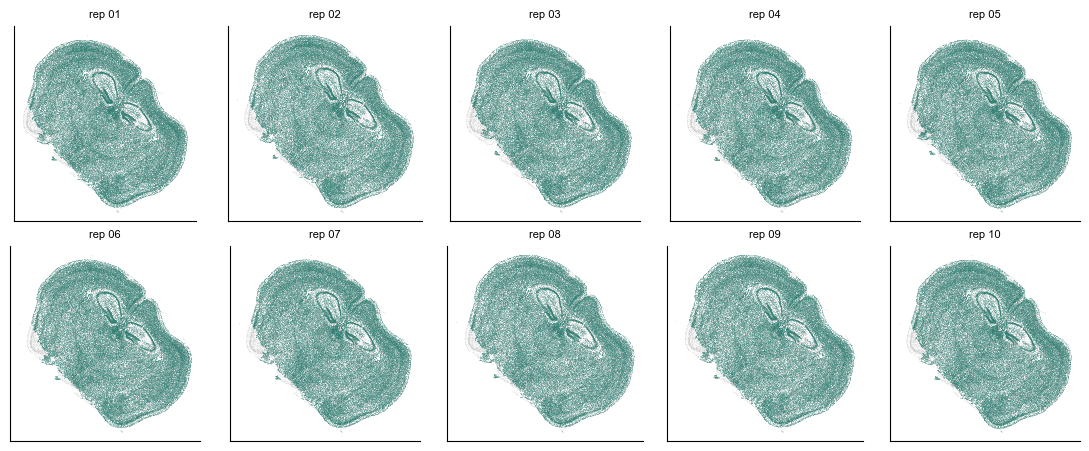

In [4]:
target_xy = uq.load_target_xy(repeat_inputs[0]["path"])
fig = uq.plot_all_replicate_overlays(aligned_by_repeat, target_xy, ncols=5)
fig.savefig(FIG_DIR / "ten_replicate_alignment_qc.svg", bbox_inches="tight")
fig.savefig(FIG_DIR / "ten_replicate_alignment_qc.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Mean distance on a fixed set of query points

Comparing the output cells from each replicate directly would mix
transformation variability with changing subsample membership. We therefore
map the same replicate-1 prealigned query points through all ten transformations.
For fixed point $p_i$ and transformation $T_r$, define

$$
z_{r,i}=T_r(p_i), \qquad
\bar z_i=\frac{1}{R}\sum_{r=1}^{R}z_{r,i}, \qquad
d_{r,i}=\lVert z_{r,i}-\bar z_i\rVert_2.
$$

The primary metric in Figure 2E is the **mean distance from the replicate-mean
mapped position**:

$$
\bar d_i=\frac{1}{R}\sum_{r=1}^{R}d_{r,i}.
$$

This is `dist_mean` in the output table and has the same units as the aligned
coordinates. The table also retains total positional spread (`std_total`),
distance standard deviation (`dist_std`) and distance variance (`dist_var`) as
secondary diagnostics. Distance variance has squared coordinate units.

In [5]:
reference_input = repeat_inputs[0]["path"]
transforms_by_repeat = uq.load_saved_transforms(OUTPUT_DIR / "transforms")
assert sorted(transforms_by_repeat) == list(range(1, 11))

mapped_fixed_query, x_fixed, y_fixed = uq.map_reference_points_through_transforms(
    transforms_by_repeat,
    reference_input_path=reference_input,
)
point_var_df, distance_to_mean = uq.compute_repeat_point_variance(
    mapped_fixed_query,
    x_fixed,
    y_fixed,
)
assert len(point_var_df) == 68_766
assert distance_to_mean.shape == (10, 68_766)

table_path = OUTPUT_DIR / "pointwise_transformation_variability.csv"
point_var_df.to_csv(table_path, index=False)
display(point_var_df.head())

,point_idx,x_src,y_src,x_mean,y_mean,var_x,var_y,dist_mean,dist_var,dist_std,var_total,std_x,std_y,std_total
0,0,1180.233643,7988.023438,1150.506262,8068.239258,3076.508486,5364.594902,82.883818,808.073130,28.426627,8441.103389,55.466282,73.243395,91.875478
1,1,1240.368408,8066.828613,1202.644531,8158.969824,3189.029231,4637.992155,79.370400,827.398700,28.764539,7827.021387,56.471490,68.102806,88.470455
2,2,1217.747070,8071.111328,1180.113599,8162.283301,3179.070562,4673.286495,79.562625,818.788915,28.614488,7852.357057,56.383247,68.361440,88.613526
3,3,1227.177734,8087.344238,1188.127136,8180.573389,3198.186568,4541.683330,78.890753,824.591106,28.715694,7739.869898,56.552512,67.392012,87.976530
4,4,1189.961548,8008.821777,1158.128394,8091.980322,3105.636957,5184.755898,82.050394,810.096047,28.462186,8290.392855,55.728242,72.005249,91.051594


## 7. Spatial map of mean distance

Replicate-1 aligned query points are colored by `dist_mean`, matching Figure
2E. The dashed ellipse summarizes the locations at or above the **95th
percentile** of mean distance. It is a visual summary, not an exact region
boundary or a confidence contour.

The color scale is capped at the **99th percentile** to preserve spatial
contrast. All points remain in the plot and in the source table.

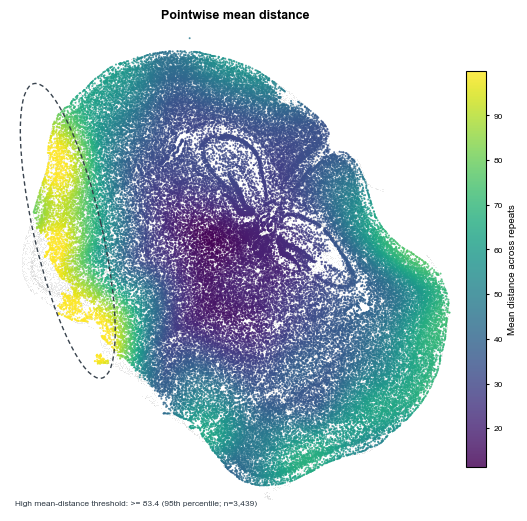

In [6]:
fig = uq.plot_distance_mean_map(
    point_var_df,
    mapped_fixed_query,
    target_xy,
    repeat=1,
    high_percentile=95.0,
    vmax_percentile=99.0,
)
for extension in ("pdf", "svg", "png"):
    fig.savefig(
        FIG_DIR / f"merfish_S2R3_to_S2R2_distance_mean_p95.{extension}",
        dpi=300, bbox_inches="tight", pad_inches=0.02,
    )
plt.show()

## 8. Distribution and numerical summary

The distribution and upper-tail count use the same `dist_mean` values as the
spatial map. The Figure 2E reference values are shown for comparison; small
floating-point differences between saved runs do not change the displayed
values or the selected top-5% points.

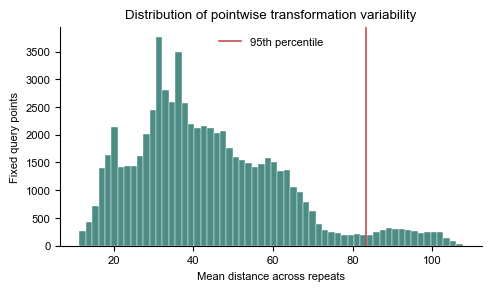

,metric,units,median,95th percentile
0,dist_mean,coordinate units,40.25,83.43
1,std_total,coordinate units,47.49,101.47
2,dist_std,coordinate units,20.73,48.51
3,dist_var,squared coordinate units,429.54,2352.74


,metric,observed,Figure 2E reference
0,median dist_mean,40.25,40.25
1,95th-percentile dist_mean,83.43,83.43
2,top-5% points,3439.00,3439.00


High mean-distance fixed query points: 3,439 / 68,766
Saved pointwise table, PDF/SVG/PNG figures, and uncertainty_report.json.


In [7]:
fig, p95_dist_mean = uq.plot_uncertainty_distribution(
    point_var_df,
    value_col="dist_mean",
    high_percentile=95.0,
)
for extension in ("pdf", "svg", "png"):
    fig.savefig(
        FIG_DIR / f"merfish_S2R3_to_S2R2_dist_mean_distribution.{extension}",
        dpi=300, bbox_inches="tight",
    )
plt.show()

metrics = ["dist_mean", "std_total", "dist_std", "dist_var"]
summary_table = pd.DataFrame(
    {
        "metric": metrics,
        "units": ["coordinate units"] * 3 + ["squared coordinate units"],
        "median": [point_var_df[c].median() for c in metrics],
        "95th percentile": [point_var_df[c].quantile(0.95) for c in metrics],
    }
)
display(summary_table.round(2))

high_mean_distance = point_var_df["dist_mean"] >= p95_dist_mean
reference_comparison = pd.DataFrame(
    {
        "metric": ["median dist_mean", "95th-percentile dist_mean", "top-5% points"],
        "observed": [
            point_var_df["dist_mean"].median(),
            p95_dist_mean,
            int(high_mean_distance.sum()),
        ],
        "Figure 2E reference": [40.248330733633516, 83.42864208609105, 3439],
    }
)
np.testing.assert_allclose(
    reference_comparison["observed"],
    reference_comparison["Figure 2E reference"],
    rtol=0, atol=1e-3,
)
display(reference_comparison.round(2))

report_path = uq.write_brief_report(
    output_dir=OUTPUT_DIR,
    summary=run_summary,
    uncertainty_df=point_var_df,
    value_col="dist_mean",
    high_percentile=95.0,
)
print(f"High mean-distance fixed query points: {high_mean_distance.sum():,} / {len(point_var_df):,}")
print("Saved pointwise table, PDF/SVG/PNG figures, and uncertainty_report.json.")

## 9. Interpretation

The largest mean distances concentrate near the weakly or incompletely
overlapping left tissue boundary, where the transformation has less shared
anatomical support. The median `dist_mean` is **40.25**, and its 95th percentile
is **83.43**, in aligned-coordinate units. There are **3,439** fixed query
points in the upper 5%.

The alignment stage retains the final optimizer iterate (`restore_best=False`).
Its two previously validated fixed-seed executions produced identical pointwise
tables; this update changes which summary metric is displayed and reuses the
same fitted transformations.

Mean distance measures **empirical subsampling-based transformation
stability**. It does not estimate a posterior probability, confidence
interval, or error relative to a known ground-truth deformation.